# Neural Prototyping

# Google Colab Mounting

In [1]:
!rm -rf /content/credit-risk-modeling
!git clone https://github.com/BillyBrothers/credit-risk-modeling.git
!pip install -r /content/credit-risk-modeling/requirements.txt

import sys 
sys.path.append('/content/credit-risk-modeling')

Cloning into 'credit-risk-modeling'...
remote: Enumerating objects: 1233, done.
remote: Counting objects: 100% (112/112), done.ects:  94% (106/112)
remote: Compressing objects: 100% (76/76), done.
remote: Total 1233 (delta 77), reused 71 (delta 36), pack-reused 1121 (from 1)
Receiving objects: 100% (1233/1233), 52.31 MiB | 28.57 MiB/s, done.
Resolving deltas: 100% (839/839), done.


In [2]:
!pip install scikeras

In [3]:
pip install -q -U keras-tuner

In [4]:
# data analysis
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pyampute.exploration.md_patterns import mdPatterns
from pyampute.exploration.mcar_statistical_tests import MCARTest
import missingno as msno

# preprocessing
import sklearn.utils.validation
import sys
from scipy import stats
from scipy.stats import shapiro, distributions, loguniform
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingRandomSearchCV, HalvingGridSearchCV, TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer, MinMaxScaler, KBinsDiscretizer, Binarizer, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from feature_engine.outliers import Winsorizer
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.pipeline import Pipeline
from sklearn import set_config

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Modeling
from sklearn.linear_model import RidgeClassifier, LogisticRegression, RidgeClassifierCV, LogisticRegressionCV, SGDClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
import joblib

# Metrics
from sklearn.metrics import confusion_matrix, recall_score, precision_score, balanced_accuracy_score, ConfusionMatrixDisplay, classification_report, precision_recall_curve, PrecisionRecallDisplay, log_loss, brier_score_loss, roc_curve, roc_auc_score, RocCurveDisplay, det_curve, DetCurveDisplay, fbeta_score, average_precision_score, matthews_corrcoef

# Calibration
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV

# Inspection
from sklearn.inspection import PartialDependenceDisplay
from credit_risk_modeling import model_eval

import tensorflow as tf
from tensorflow import keras
from keras import layers
from scikeras.wrappers import KerasClassifier
import keras_tuner as kt

2026-02-06 18:53:48.030 | INFO     | credit_risk_modeling.config:<module>:11 - PROJ_ROOT path is: /content/credit-risk-modeling


In [5]:
!ls

credit-risk-modeling  logs  sample_data


In [6]:
!ls credit-risk-modeling

credit_risk_modeling  LICENSE	 pyproject.toml  requirements.txt
data		      Makefile	 README.md	 tests
docs		      models	 references
environment.yml       notebooks  reports


# Imports

In [7]:
X_train = pd.read_csv(
    filepath_or_buffer= "/content/credit-risk-modeling/data/processed/X_train_neural.csv"
)

In [8]:
X_test = pd.read_csv(
    filepath_or_buffer= "/content/credit-risk-modeling/data/processed/X_test_neural.csv"
)

In [9]:
X_val = pd.read_csv(
    filepath_or_buffer= "/content/credit-risk-modeling/data/processed/X_val_neural.csv"
)

In [10]:
y_train= pd.read_csv(
    filepath_or_buffer= "/content/credit-risk-modeling/data/interim/y_train.csv"
)
y_train = y_train.values.ravel()
neg, pos = np.bincount(y_train)
total = neg + pos
print(f"Examples:\n The training sets total amount of samples: {total}\n Positive: {pos} ({pos/total*100:.2f}% of total)")

Examples:
 The training sets total amount of samples: 22686
 Positive: 4962 (21.87% of total)


In [11]:
y_test = pd.read_csv(
    filepath_or_buffer= "/content/credit-risk-modeling/data/interim/y_test.csv"
)
y_test = y_test.values.ravel()
neg, pos = np.bincount(y_test)
total = neg + pos
print(f"Examples:\n The testing set total amount of samples: {total}\n Positive: {pos} ({pos/total*100:.2f}% of total)")

Examples:
 The testing set total amount of samples: 2917
 Positive: 638 (21.87% of total)


In [12]:
y_val = pd.read_csv(
    filepath_or_buffer= "/content/credit-risk-modeling/data/interim/y_val.csv"
)
y_val = y_val.values.ravel()
neg, pos = np.bincount(y_val)
total = neg + pos
print(f"Examples:\n The validation set total amount of samples: {total}\n Positive: {pos} ({pos/total*100:.2f}% of total)")

Examples:
 The validation set total amount of samples: 6806
 Positive: 1488 (21.86% of total)


# Build Sequential Models

In [13]:
# # Architecture 1: Single hidden dense layer
def mlp1():
    model = keras.Sequential(name='MLP-1')
    model.add(keras.Input(shape=(X_train.shape[1], ))),
    model.add(layers.Dense(units=64, activation='relu')),
    model.add(layers.Dropout(rate= 0.20)),
    model.add(layers.Dense(units=1,activation='sigmoid')),
    model.compile(
        optimizer= keras.optimizers.Adam(),
        loss= keras.losses.BinaryCrossentropy(),
        metrics= [keras.metrics.AUC(curve="ROC", name="auc")]
)
    return model

In [14]:
# def mlp1(hp):
#     model1 = keras.Sequential(name='MLP-1')
#     model1.add(keras.Input(shape=(X_train.shape[1], )))

#     hp_units= hp.Int('units', min_value=64, max_value=512, step=32)
#     hp_lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

#     model1.add(layers.Dense(units=hp_units, activation='relu'))
#     model1.add(layers.Dropout(rate= 0.20))
#     model1.add(layers.Dense(units=1,activation='sigmoid'))
    
#     model1.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
#                 loss=keras.losses.BinaryCrossentropy(),
#                 metrics= [keras.metrics.AUC(curve="ROC", name="auc")]
#     ) 
#     return model1

In [15]:
# Architecture 2: Two hidden dense layers
def mlp2():
    model = keras.Sequential(name='MLP-2')
    model.add(keras.Input(shape=(X_train.shape[1], ))),
    model.add(layers.Dense(units=64, activation='relu')),
    model.add(layers.Dropout(rate= 0.20)),
    model.add(layers.Dense(units=128, activation='relu')),
    model.add(layers.Dropout(rate=0.20)),
    model.add(layers.Dense(units=1,activation='sigmoid')),
    
    model.compile(optimizer=keras.optimizers.Adam(),
                loss=keras.losses.BinaryCrossentropy(),
                metrics= [keras.metrics.AUC(curve="ROC", name="auc")]
    )
    return model

In [16]:
# # Architecture 2: Two hidden dense layers
# def mlp2(hp):
#     model2 = keras.Sequential(name='MLP-2')
#     model2.add(keras.Input(shape=(X_train.shape[1], ))),
#     hp_units= hp.Int('units', min_value=64, max_value=512, step=32)
#     model2.add(layers.Dense(units=hp_units, activation='relu')),
#     model2.add(layers.Dropout(rate= 0.20)),
#     hp_units= hp.Int('units', min_value=64, max_value=512, step=32)
#     model2.add(layers.Dense(units=hp_units, activation='relu')),
#     model2.add(layers.Dropout(rate=0.20)),
#     model2.add(layers.Dense(units=1,activation='sigmoid')),
#     model2.compile(optimizer=keras.optimizers.Adam(),
#                 loss=keras.losses.BinaryCrossentropy(),
#                 metrics= [keras.metrics.AUC(curve="ROC", name="auc")]
#     )
#     return model2

In [17]:
# Architecture 3: Three hidden dense layers
def mlp3():
    model = keras.Sequential(name='MLP-3')
    model.add(keras.Input(shape=(X_train.shape[1], ))),
    model.add(layers.Dense(units=64, activation='relu')),
    model.add(layers.Dropout(rate= 0.20)),
    model.add(layers.Dense(units=128, activation='relu')),
    model.add(layers.Dropout(rate=0.20)),
    model.add(layers.Dense(units=256, activation='relu')),
    model.add(layers.Dropout(rate=0.2)),
    model.add(layers.Dense(units=1,activation='sigmoid')),

    model.compile(
        optimizer= keras.optimizers.Adam(),
        loss= keras.losses.BinaryCrossentropy(),
        metrics= [keras.metrics.AUC(curve="ROC", name="auc")]
)
    return model

In [18]:
# def mlp3(hp):
#     model3 = keras.Sequential(name='MLP-3')
#     model3.add(keras.Input(shape=(X_train.shape[1], ))),
#     hp_units= hp.Int('units', min_value=64, max_value=512, step=32)
#     model3.add(layers.Dense(units=hp_units, activation='relu')),
#     model3.add(layers.Dropout(rate= 0.20)),
#     hp_units= hp.Int('units', min_value=64, max_value=512, step=32)
#     model3.add(layers.Dense(units=hp_units, activation='relu')),
#     model3.add(layers.Dropout(rate=0.20)),
#     hp_units= hp.Int('units', min_value=64, max_value=512, step=32)
#     model3.add(layers.Dense(units=hp_units, activation='relu')),
#     model3.add(layers.Dropout(rate=0.2)),
#     model3.add(layers.Dense(units=1,activation='sigmoid')),
#     model3.compile(optimizer=keras.optimizers.Adam(),
#                 loss=keras.losses.BinaryCrossentropy(),
#                 metrics= [keras.metrics.AUC(curve="ROC", name="auc")]
#     )

#     return model3

In [19]:
mlp_models = [
    ("MLP-1", mlp1()),
    ("MLP-2", mlp2()),
    ("MLP-3", mlp3())
]

### Callbacks

In [20]:
reduce_lr_plateau = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=0.001
)

In [21]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=7,
    verbose=1,
    restore_best_weights=True
)

In [22]:
log_dir = "logs/fit/"
tensorboard = keras.callbacks.TensorBoard(
    log_dir= log_dir
)

### Fit

In [23]:
class_weight = {
    0: 1.0,
    1: 2.0
    }

In [24]:
histories = {}

In [25]:
for model_name, model in mlp_models:
    print(f"Currently fitting model {model_name}.")
    history = model.fit(
        x= X_train,
        y= y_train,
        batch_size=32,
        epochs= 100,
        verbose=2,
        callbacks= [early_stopping, reduce_lr_plateau, tensorboard],
        validation_data= (X_val, y_val),
        class_weight= class_weight
    )
    histories[model_name] = history.history

Currently fitting model MLP-1.
Epoch 1/100
709/709 - 3s - 4ms/step - auc: 0.8487 - loss: 0.5584 - val_auc: 0.8916 - val_loss: 0.3426 - learning_rate: 1.0000e-03
Epoch 2/100
709/709 - 1s - 2ms/step - auc: 0.8881 - loss: 0.4804 - val_auc: 0.9015 - val_loss: 0.3314 - learning_rate: 1.0000e-03
Epoch 3/100
709/709 - 2s - 2ms/step - auc: 0.8945 - loss: 0.4644 - val_auc: 0.9034 - val_loss: 0.3166 - learning_rate: 1.0000e-03
Epoch 4/100
709/709 - 2s - 3ms/step - auc: 0.8993 - loss: 0.4525 - val_auc: 0.9070 - val_loss: 0.3087 - learning_rate: 1.0000e-03
Epoch 5/100
709/709 - 2s - 2ms/step - auc: 0.9012 - loss: 0.4459 - val_auc: 0.9089 - val_loss: 0.3077 - learning_rate: 1.0000e-03
Epoch 6/100
709/709 - 2s - 2ms/step - auc: 0.9034 - loss: 0.4389 - val_auc: 0.9109 - val_loss: 0.3007 - learning_rate: 1.0000e-03
Epoch 7/100
709/709 - 2s - 3ms/step - auc: 0.9051 - loss: 0.4336 - val_auc: 0.9125 - val_loss: 0.2884 - learning_rate: 1.0000e-03
Epoch 8/100
709/709 - 2s - 2ms/step - auc: 0.9074 - loss: 0

In [26]:
chosen_metric = 'val_auc'
max_auc_per_model = {}
best_auc = None
best_model = None
best_model_name = None

for model_name, model in mlp_models:
    max_auc_per_model[model_name] = max(histories[model_name][chosen_metric])
    max_auc_dict = dict([sorted(max_auc_per_model.items(), key= lambda item: item[1])[-1]])
    max_auc_model_name = list(max_auc_dict.keys())[0]
    max_aux_score = list(max_auc_dict.values())[0]
    if max_auc_model_name == model_name:
        best_auc = max_aux_score
        best_model_name = max_auc_model_name
        best_model = model
    else:
        continue

print(f"Results: \nBest model: {best_model_name}\nAUC score: {best_auc:.4f}")

Results: 
Best model: MLP-3
AUC score: 0.9253


In [27]:
best_model.summary()

Model: "MLP-3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,645 (502.52 KB)

 Trainable params: 42,881 (167.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 85,764 (335.02 KB)

### Hyperparameter Tuning

In [28]:
# for tid, t in tuner.oracle.trials.items():
#     print(tid, t.status, t.score)

In [29]:
# def mlp2_tuned(hp):
#     model = keras.Sequential(name='MLP-2-tuned')

#     units = hp.Int("units", 64, 256, step=32)
#     lr = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")

#     model.add(keras.Input(shape=(X_train.shape[1], ))),
#     model.add(layers.Dense(units=units, activation='relu')),
#     model.add(layers.Dropout(rate= 0.20)),
#     model.add(layers.Dense(units=units, activation='relu')),
#     model.add(layers.Dropout(rate=0.20)),
#     model.add(layers.Dense(units=1,activation='sigmoid')),
    
#     model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
#                 loss=keras.losses.BinaryCrossentropy(),
#                 metrics= [keras.metrics.AUC(curve="ROC", name="auc")]
#     )
#     return model

In [30]:
# import shutil
# shutil.rmtree("untitled_project", ignore_errors=True)

In [31]:
# tuner = kt.Hyperband(
#     hypermodel= mlp2_tuned,
#     objective="val_auc",
#     max_epochs= 50,
#     factor=3,
# )

In [32]:
# tuner.search_space_summary()

In [33]:
# tuner.search(
#     X_train,
#     y_train,
#     validation_data= (X_val, y_val),
#     callbacks= [early_stopping]
# )

In [34]:
# tuner.results_summary()

### Calibration

Scikeras cannot accept an instance of a model only a user building function (factory function). So, my model will have NO weights on it.

In [35]:
models_only = {}
mlp_functions = []

In [36]:
for model_name, model in mlp_models:
    models_only[model_name] = KerasClassifier(
    model= model,
    optimizer= keras.optimizers.Adam(),
    loss= keras.losses.BinaryCrossentropy(),
    random_state=42,
    class_weight= class_weight,
    metrics= ['val_auc'],
    callbacks= [early_stopping, reduce_lr_plateau],
    validation_split= 0.20,
    epochs=100
)

In [37]:
for model_name, model in list(models_only.items()):
    mlp_functions.append(model)

In [40]:
models_performances, fitted_models = model_eval.comparing_models(
    mlp_functions,
    X_train,
    y_train,
    X_test,
    y_test
)

Epoch 1/100
568/568 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - auc: 0.9231 - loss: 0.3650 - val_auc: 0.9277 - val_loss: 0.3662 - learning_rate: 0.0010
Epoch 2/100
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9228 - loss: 0.3626 - val_auc: 0.9264 - val_loss: 0.3679 - learning_rate: 0.0010
Epoch 3/100
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9223 - loss: 0.3640 - val_auc: 0.9259 - val_loss: 0.3694 - learning_rate: 0.0010
Epoch 4/100
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9234 - loss: 0.3642 - val_auc: 0.9256 - val_loss: 0.3702 - learning_rate: 0.0010
Epoch 5/100
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9219 - loss: 0.3661 - val_auc: 0.9257 - val_loss: 0.3696 - learning_rate: 0.0010
Epoch 6/100
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9248 - loss: 0.3622 - val_auc: 0.9252 - val_loss: 0.3706 - learning_rate: 0.0010
Epoch 7/100
568/568 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.9218 - loss: 0.3675 - val_auc: 0.9255 - val_loss: 0.3698 - learning_rate: 0.0010

In [42]:
models_performances

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef
1,"MLP-2 (class_weight={0: 1.0, 1: 2.0})",0.919975,0.856480,0.255240,0.074045,0.734431
2,"MLP-3 (class_weight={0: 1.0, 1: 2.0})",0.918778,0.856215,0.255224,0.073705,0.735568
0,"MLP-1 (class_weight={0: 1.0, 1: 2.0})",0.915466,0.845577,0.273037,0.080378,0.705309


In [85]:
roc_auc = models_performances.loc[:,'roc_auc']

In [76]:
clean_functions = {"mlp1": mlp1(), 
 "mlp2": mlp2(), 
 "mlp3": mlp3()},

In [79]:
clean_functions_df = pd.DataFrame(
    data= clean_functions,
    index= range(0,1)
)

In [86]:
clean_functions_df

,mlp1,mlp2,mlp3
0,"<Sequential name=MLP-1, built=True>","<Sequential name=MLP-2, built=True>","<Sequential name=MLP-3, built=True>"


AttributeError: 'super' object has no attribute '__sklearn_tags__'

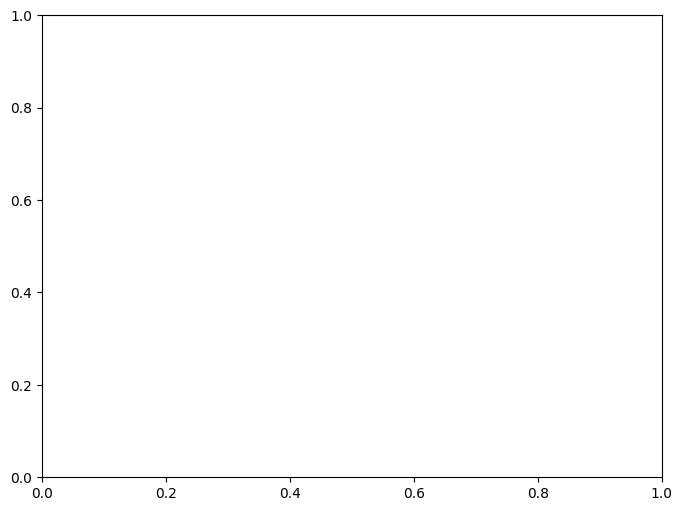

In [56]:
top_performing_calibrated_models = model_eval.evaluate_calibration(
    models_performances,
    fitted_models,
    X_train,
    y_train,
    X_test, 
    y_test
)

In [57]:
top_model_name = models_performances.iloc[0]['model']
top_performing_model = fitted_models[top_model_name]
methods = ['sigmoid', 'isotonic']

calibrated_models = {}   # store models here

# fig, ax = plt.subplots(figsize=(8,6))

for method in methods:
    # Fit calibrated model
    calibrated_model = CalibratedClassifierCV(
        estimator=top_performing_model,
        method=method,
        n_jobs=-1
    ).fit(X_train, y_train)

AttributeError: 'super' object has no attribute '__sklearn_tags__'